# Importing modules
__________________
The modules involves Numpy, Pandas, Matplotlib, Seaborn

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns #Visualizations
from matplotlib import pyplot as plt
%matplotlib inline
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))

# Any results you write to the current directory are saved as output.

gender_submission.csv
test.csv
train.csv



# Spliting values in variables

In [2]:
train_data = pd.read_csv("../input/train.csv")
test_data = pd.read_csv("../input/test.csv")
files_listing = test_data.PassengerId
test_labels = pd.read_csv('../input/gender_submission.csv')

# Printing the training data 

In [3]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Striping down the data
---
The data contains a lot of useless information. The columns containing these data will need to be dropped.
Classifiers do not take non integral values as input and so needs to be converted. So Sex column in manipulated 

In [4]:
labels_test = test_labels.values
labels_test = labels_test[:,1]
test_data = test_data.drop(['Name','SibSp','Parch','Ticket','Fare','Cabin','Embarked'], axis=1)
test_data.Age = test_data.Age.fillna(np.mean(train_data.Age))
test_data.Sex = test_data.Sex.apply(lambda x: 1 if x=='male' else 0)
test_data = test_data.values
test_data = test_data[:,1:]
features_test = test_data

In [5]:
train_data = train_data.drop(['Name','SibSp','Parch','Ticket','Fare','Cabin','Embarked'], axis=1)

In [6]:
train_data['Age'] = train_data['Age'].fillna(np.mean(train_data.Age))
train_data['Sex'] = train_data['Sex'].apply(lambda x: 1 if x == 'male' else 0)
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,1,22.0
1,2,1,1,0,38.0
2,3,1,3,0,26.0
3,4,1,1,0,35.0
4,5,0,3,1,35.0


Converting data from dataframe into numpy array and segragating features and labels.

In [7]:
#Getting all the values from the dataframe to the numpy array
features_all = train_data.values

#Droping the Passenger Id Column and changing spilting the features and labels
labels_all = features_all[:,1]
features_all = features_all[:,2:]

# Showdown of Classifiers
All the algorithms are tested and the accuracy score is generated

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

classifiers = [
    KNeighborsClassifier(),
    AdaBoostClassifier(),
    RandomForestClassifier(),
    GaussianNB(),
    LinearDiscriminantAnalysis(),
    GradientBoostingClassifier(),
    DecisionTreeClassifier()
]
uni, cnt = np.unique(labels_test, return_counts=True)
res_cols = ['Name','Accuracy']
result = pd.DataFrame(columns=res_cols)
print("Actual Value of the result ",dict(zip(uni, cnt)))
for clf in classifiers:
    clf.fit(features_all, labels_all)
    print("-"*50)
    name=clf.__class__.__name__
    print(name)
    pred_train = clf.predict(features_test)
    acc = accuracy_score(labels_test, pred_train)
    print("Result ->", acc*100,'%')
    frame = pd.DataFrame([[name, acc*100]],columns=res_cols)
    result = result.append(frame)
print('-'*50)

Actual Value of the result  {0: 266, 1: 152}
--------------------------------------------------
KNeighborsClassifier
Result -> 77.7511961722 %
--------------------------------------------------
AdaBoostClassifier
Result -> 92.1052631579 %
--------------------------------------------------
RandomForestClassifier
Result -> 86.8421052632 %
--------------------------------------------------
GaussianNB
Result -> 99.7607655502 %
--------------------------------------------------
LinearDiscriminantAnalysis
Result -> 99.043062201 %
--------------------------------------------------
GradientBoostingClassifier
Result -> 92.5837320574 %
--------------------------------------------------
DecisionTreeClassifier
Result -> 86.1244019139 %
--------------------------------------------------


# Showdown of SVM's
All the SVM are tuned with different kernel and C parameter tuning and the accuracy is generated

In [9]:
classifiers = [
    LinearSVC(),
    NuSVC(),
    SVC(kernel="rbf",C=0.25),
    SVC(kernel="linear",C=0.25),
    SVC(kernel="rbf",C=1),
    SVC(kernel="linear",C=1),
    SVC(kernel="rbf",C=5),
    SVC(kernel="linear",C=5)
]
uni, cnt = np.unique(labels_test, return_counts=True)
print("Actual Value of the result ",dict(zip(uni, cnt)))
for clf in classifiers:
    clf.fit(features_all, labels_all)
    print("-"*50)
    name = clf.__class__.__name__
    print(name)
    pred_train = clf.predict(features_test)
    acc = accuracy_score(labels_test, pred_train)
    print("Result ->", acc*100,'%')
print('-'*50)

Actual Value of the result  {0: 266, 1: 152}
--------------------------------------------------
LinearSVC
Result -> 83.014354067 %
--------------------------------------------------
NuSVC
Result -> 90.6698564593 %
--------------------------------------------------
SVC
Result -> 81.8181818182 %
--------------------------------------------------
SVC
Result -> 100.0 %
--------------------------------------------------
SVC
Result -> 90.9090909091 %
--------------------------------------------------
SVC
Result -> 100.0 %
--------------------------------------------------
SVC
Result -> 88.995215311 %
--------------------------------------------------
SVC
Result -> 100.0 %
--------------------------------------------------


# Comparision plot for Algorithms

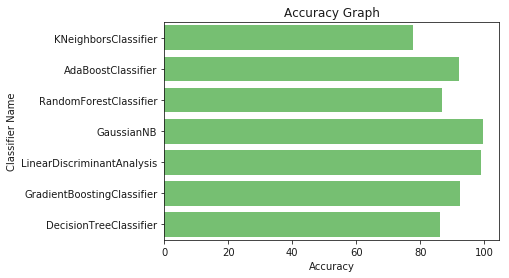

In [10]:
sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y="Name", data=result,color='g')
plt.xlabel("Accuracy")
plt.ylabel("Classifier Name")
plt.title("Accuracy Graph")
plt.show()